In [ ]:
from GWFish.GWFish.modules.detection import Network
from GWFish.GWFish.modules.fishermatrix import compute_network_errors
import GWFish.GWFish as gw

import pandas as pd
import numpy as np
import lal
import numpy.random as rng
import matplotlib.pyplot as plt

import time

from few.waveform import GenerateEMRIWaveform
from few.utils.constants import MTSUN_SI
from few.utils.utility import get_p_at_t
from few.utils.geodesic import get_fundamental_frequencies
from few.utils.fdutils import GetFDWaveformFromFD, GetFDWaveformFromTD
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import KerrEccEqFlux

from scipy.interpolate import CubicSpline
from few import get_file_manager




/Users/pmxks13/Library/Python/3.9/lib/python/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

In [56]:
td_gen = GenerateEMRIWaveform(
    "FastKerrEccentricEquatorialFlux",
    sum_kwargs=dict(pad_output=True, odd_len=True),
    return_list=True,
)

In [185]:
# produce sensitivity function
traj_module = EMRIInspiral(func=KerrEccEqFlux)

# import ASD
data = np.loadtxt(get_file_manager().get_file("LPA.txt"), skiprows=1)
data[:, 1] = data[:, 1] ** 2
# define PSD function
get_sensitivity = CubicSpline(*data.T)


# define inner product [eq 3 of https://www.nature.com/articles/s41550-022-01849-y]
def inner_product(x, y, psd):
    return 4 * np.real(np.sum(np.conj(x) * y / psd))

def SNR_calc(m1, m2, a, e0, x0, Tobs, dt, mode_selection_threshold, printing=True):
    truestart = time.time()

    #to be randomised
    qK = np.pi / 3   # polar spin angle
    phiK = np.pi / 3 # azimuthal viewing angle
    qS = np.pi / 3   # polar sky angle
    phiS = np.pi / 3 # azimuthal viewing angle
    dist = 1.0       # luminosity distance (Gpc)
    # initial phases
    Phi_phi0 = np.pi / 3
    Phi_theta0 = 0.0
    Phi_r0 = np.pi / 3

    waveform_kwargs = {
        "T": Tobs,
        "dt": dt,
        "mode_selection_threshold": mode_selection_threshold,
    }
    start = time.time()

    # get the initial p0 required for an inspiral of length Tobs, given the fixed values of the other parameters
    p0 = get_p_at_t(
        traj_module,
        Tobs * 0.999,
        [m1, m2, a, e0, 1.0],       # list of trajectory arguments, with p removed
        index_of_p=3,               # index where to insert the new p values in the above traj_args list when traj_module is called
        index_of_a=2,               # index of a in the list of trajectory arguments when calling traj_module
        index_of_e=4,               # etc...
        index_of_x=5,
        traj_kwargs={},
        xtol=2e-12,                 # absolute tolerance for the brentq root finder
        rtol=8.881784197001252e-16, # relative tolerance for the brentq root finder
        bounds=None,
    )
    # print("New p0: ", p0)
    end = time.time()
    # print("Time taken to find p0: ", end - start, "seconds")
    p0_time=end - start

    emri_injection_params = [m1, m2, a, p0, e0, x0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,]

    # generate the TD signal, and time how long it takes
    start = time.time()
    data_channels_td = td_gen(*emri_injection_params, **waveform_kwargs) # Returns 2 arrays containing the plus and cross polarizations
    end = time.time()
    # print("Time taken to generate the TD signal: ", end - start, "seconds")
    td_time=end - start

    start = time.time()
    # take the FFT of the plus polarization and shift it
    fft_TD = np.fft.fftshift(np.fft.fft(data_channels_td[0])) * dt
    freq = np.fft.fftshift(np.fft.fftfreq(len(data_channels_td[0]), dt))

    # define the positive frequencies
    positive_frequency_mask = freq >= 0.0

    # calculate the mismatch between the FFT'd TD waveform and the direct FD waveform:
    psd = get_sensitivity(freq[positive_frequency_mask]) / np.diff(freq)[0]
    td_td = inner_product(fft_TD[positive_frequency_mask], fft_TD[positive_frequency_mask], psd)

    end = time.time()
    total_time=end - truestart
    snr_time=end - start

    SNR=np.sqrt(td_td)

    # print("Time taken to calculate the SNR: ", end - start, "seconds")
    if printing==True:
        print(f"Total time taken: {total_time} s\n p0: {p0_time} s, td: {td_time} s, snr: {snr_time} s")
        print("TD SNR:", np.sqrt(td_td))
    return SNR, [total_time, p0_time, td_time, snr_time]

In [ ]:
BIMF='Bartos'
BH='1.0e+06'
DT="SG"
a=0.1
spin=0.9
tdisk=10.0
wind='Partial'
TT='P10'
N=6311

filename=f'EMRI_Rates/{BIMF}/MBH_{BH}/{DT}/alpha_{a}/spin_{spin}/Tdisk_{tdisk}/wind_{wind}/EMRIs_{TT}_1g_{N}.txt'

with open(filename) as f:
    lines = f.readlines()

header_end = lines.index("Data:\n") + 1

for i in range (4, header_end-2):
    print(f'{lines[i].split(" = ")[0]}={lines[i].split(" = ")[1]}')

alpha=lines[6].split("= ",1)[1]
alpha=alpha.split('\n')[0]
print(float(alpha))

Mbh=lines[9].split("= ",1)[1]
Mbh=float(Mbh.split('\n')[0])
print(Mbh)

data = pd.read_csv(filename, delimiter=" ", skiprows=header_end)

data.columns = [col.strip().replace(",", "") for col in data.columns]
print(data.keys())

N=len(data["m1/Msun"])
print(f'Columns: {header_end}, Rows: {N}')

m1=data['m1/Msun']
print(m1[0])

disk_type=SG

torque_type=P10

alpha=0.1

gen=1g

N=6311

M_SMBH=1000000.0

Spin=0.9

T=10.0

0.1
1000000.0
Index(['m1/Msun', 'r0/Rg', 'cos_i', 't_align/Myr', 't_gw/Myr', 't_migr/Myr',
       't_inspiral/Myr', 'Ng', 'R_final/Rg', 'lisa_radii/Rg', 't_lisa/Myr',
       't_final/Myr', 'lisa_flag', 'total_flags'],
      dtype='object')
Columns: 14, Rows: 81
7.262


In [ ]:
Tobs = 4  # observation time (years), if the inspiral is shorter, the it will be zero padded
dt = 5.0    # time interval (seconds)
mode_selection_threshold = 1e-4  # relative threshold for mode inclusion: only modes making a relative contribution to
            # the total power above this threshold will be included in the waveform.
x0 = 1.0 #initial cos(inclination) - fine to assume as 1 due to short timescale of alignment compared to inspiral
e0 = 0  # eccentricity - assumed circular in runs anyway
m1 = Mbh # central object mass (solar masses)
a = spin   # dimensionless spin parameter for the primary - will be ignored in Schwarzschild waveform

SNR_time=[]
SNRs_20s=[]

for i in range(0, N):
    truestart = time.time()
    # define the injection parameters
    m2 = data['m1/Msun'][i]  # secondary object mass (solar masses)
    # p0 = 2*data['r0/Rg'][i]  # initial dimensionless semi-latus rectum

    print(f'\ni:{i}, m2: {m2} Msun')
    SNR, timings=SNR_calc(m1, m2, a, e0, x0, Tobs, dt, mode_selection_threshold, printing=True)
    
    SNR_time.append(timings[0])
    SNRs_20s.append(SNR)

mean=np.mean(SNR_time)
sd=np.std(SNR_time)

print(f"Avg. time: {mean} s")
print(f"Avg. time: {sd} s")


i:0, m2: 7.262 Msun
Time taken to find p0:  0.605309247970581 seconds
Time taken to generate the TD signal:  3.982233762741089 seconds
Time taken to calculate the SNR:  7.476710796356201 seconds
Total time taken:  12.064664602279663 seconds
TD SNR 89.50426451682188

i:1, m2: 17.29 Msun
Time taken to find p0:  0.5959908962249756 seconds
Time taken to generate the TD signal:  3.6839537620544434 seconds
Time taken to calculate the SNR:  9.973092794418335 seconds
Total time taken:  14.254824876785278 seconds
TD SNR 145.19848140871164

i:2, m2: 7.04 Msun
Time taken to find p0:  0.5502529144287109 seconds
Time taken to generate the TD signal:  3.9568281173706055 seconds
Time taken to calculate the SNR:  10.19880723953247 seconds
Total time taken:  14.70695424079895 seconds
TD SNR 87.88967826968141

i:3, m2: 10.01 Msun
Time taken to find p0:  0.5913491249084473 seconds
Time taken to generate the TD signal:  3.7914631366729736 seconds
Time taken to calculate the SNR:  11.368920087814331 secon

In [172]:
dts=5.0, 10.0, 25.0, 30.0, 45.0, 60.0, 75.0, 90.0, 105.0, 120.0
SNRs_diff=[]
SNRs_sds=[]
time_p0=[]
time_TD=[]
time_SNR=[]
time_total=[]

In [173]:
for dt in dts:
    print(f'dt: {dt} s')
    Tobs = 4  # observation time (years), if the inspiral is shorter, the it will be zero padded
    dt = dt    # time interval (seconds)
    mode_selection_threshold = 1e-4  # relative threshold for mode inclusion: only modes making a relative contribution to
                # the total power above this threshold will be included in the waveform.
    x0 = 1.0 #initial cos(inclination) - fine to assume as 1 due to short timescale of alignment compared to inspiral
    e0 = 0  # eccentricity - assumed circular in runs anyway
    m1 = Mbh # central object mass (solar masses)
    a = spin   # dimensionless spin parameter for the primary - will be ignored in Schwarzschild waveform

    SNR_time=[]
    total_time=[]
    TD_time=[]
    p0_time=[]
    SNRs=[]

    for i in range(0, N):
        truestart = time.time()
        # define the injection parameters
        m2 = data['m1/Msun'][i]  # secondary object mass (solar masses)
        # p0 = 2*data['r0/Rg'][i]  # initial dimensionless semi-latus rectum

        print(f'\ni:{i}, m2: {m2} Msun')

        #to be randomised
        qK = np.pi / 3   # polar spin angle
        phiK = np.pi / 3 # azimuthal viewing angle
        qS = np.pi / 3   # polar sky angle
        phiS = np.pi / 3 # azimuthal viewing angle
        dist = 1.0       # luminosity distance (Gpc)
        # initial phases
        Phi_phi0 = np.pi / 3
        Phi_theta0 = 0.0
        Phi_r0 = np.pi / 3

        waveform_kwargs = {
            "T": Tobs,
            "dt": dt,
            "mode_selection_threshold": mode_selection_threshold,
        }
        start = time.time()

        # get the initial p0 required for an inspiral of length Tobs, given the fixed values of the other parameters
        p0 = get_p_at_t(
            traj_module,
            Tobs * 0.999,
            [m1, m2, a, e0, 1.0],       # list of trajectory arguments, with p removed
            index_of_p=3,               # index where to insert the new p values in the above traj_args list when traj_module is called
            index_of_a=2,               # index of a in the list of trajectory arguments when calling traj_module
            index_of_e=4,               # etc...
            index_of_x=5,
            traj_kwargs={},
            xtol=2e-12,                 # absolute tolerance for the brentq root finder
            rtol=8.881784197001252e-16, # relative tolerance for the brentq root finder
            bounds=None,
        )
        # print("New p0: ", p0)
        end = time.time()
        # print("Time taken to find p0: ", end - start, "seconds")
        p0_time.append(end - start)

        emri_injection_params = [m1, m2, a, p0, e0, x0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,]

        # generate the TD signal, and time how long it takes
        start = time.time()
        data_channels_td = td_gen(*emri_injection_params, **waveform_kwargs) # Returns 2 arrays containing the plus and cross polarizations
        end = time.time()
        # print("Time taken to generate the TD signal: ", end - start, "seconds")
        TD_time.append(end - start)

        start = time.time()
        # take the FFT of the plus polarization and shift it
        fft_TD = np.fft.fftshift(np.fft.fft(data_channels_td[0])) * dt
        freq = np.fft.fftshift(np.fft.fftfreq(len(data_channels_td[0]), dt))

        # define the positive frequencies
        positive_frequency_mask = freq >= 0.0

        # calculate the mismatch between the FFT'd TD waveform and the direct FD waveform:
        psd = get_sensitivity(freq[positive_frequency_mask]) / np.diff(freq)[0]
        td_td = inner_product(fft_TD[positive_frequency_mask], fft_TD[positive_frequency_mask], psd)

        end = time.time()
        timing=end - truestart

        # print("Time taken to calculate the SNR: ", end - start, "seconds")
        print("Total time taken: ", timing, "seconds")
        # SNR
        print("TD SNR", np.sqrt(td_td))
        SNR_time.append(end - start)
        total_time.append(timing)
        SNRs.append(np.sqrt(td_td))

    mean=np.mean(total_time)
    sd=np.std(total_time)

    print(f"Avg. time: {mean}±{sd} s")

    dif=np.array(SNRs_20s)-np.array(SNRs)

    SNRs_diff.append(np.mean(dif))
    SNRs_sds.append(np.std(dif))
    time_p0.append(np.mean(p0_time))
    time_TD.append(np.mean(TD_time))
    time_SNR.append(np.mean(SNR_time))
    time_total.append(np.mean(total_time))


dt: 5.0 s

i:0, m2: 7.262 Msun
Total time taken:  18.08995485305786 seconds
TD SNR 89.50426451682188

i:1, m2: 17.29 Msun
Total time taken:  14.827911138534546 seconds
TD SNR 145.19848140871164

i:2, m2: 7.04 Msun
Total time taken:  13.896223068237305 seconds
TD SNR 87.88967826968141

i:3, m2: 10.01 Msun
Total time taken:  12.827760696411133 seconds
TD SNR 107.59122700922859

i:4, m2: 7.96 Msun
Total time taken:  12.240190029144287 seconds
TD SNR 94.41143618825163

i:5, m2: 5.241 Msun
Total time taken:  14.101855993270874 seconds
TD SNR 73.624304329474

i:6, m2: 32.07 Msun
Total time taken:  14.100501775741577 seconds
TD SNR 201.04590807474864

i:7, m2: 6.811 Msun
Total time taken:  15.555860042572021 seconds
TD SNR 86.19462090518192

i:8, m2: 5.644 Msun
Total time taken:  12.780997276306152 seconds
TD SNR 77.02790171561641

i:9, m2: 6.277 Msun
Total time taken:  13.754547834396362 seconds
TD SNR 82.11644837412278

i:10, m2: 5.241 Msun
Total time taken:  12.258556127548218 seconds
TD S

In [174]:
SNRs_difference=[]

for i in range(0, len(SNRs_diff)):
    print(np.mean(SNRs_diff[i]))
    SNRs_difference.append(np.sqrt(np.mean(SNRs_diff[i])**2))

print(SNRs_diff)


0.0
1.534842559163471e-05
2.5621419433964605e-05
-2.0934017298674727e-06
-0.04670269759466858
0.20933094794663987
2.8528887396162315
7.378282505457838
12.913280093922719
19.09781671223887
[0.0, 1.534842559163471e-05, 2.5621419433964605e-05, -2.0934017298674727e-06, -0.04670269759466858, 0.20933094794663987, 2.8528887396162315, 7.378282505457838, 12.913280093922719, 19.09781671223887]


[11.124300944952317, 5.1911950052520375, 2.1752748901461376, 2.3741737648292824, 1.89412248281785, 1.6779137423009047, 1.5416468102254985, 1.4774488666911183, 1.3760636529804748, 1.311097565992379]


/var/folders/p3/zq_xf6g554d28rrxhsngpp_00000gr/T/ipykernel_71313/1581016247.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


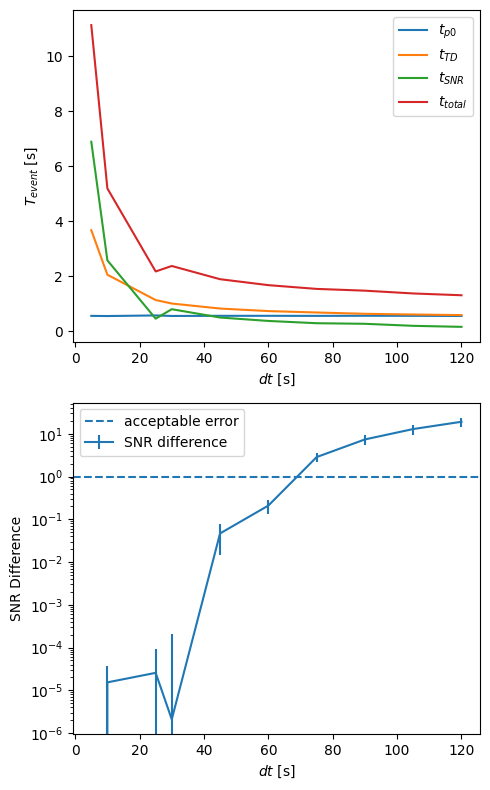

In [184]:

fig, (ax, ax2) = plt.subplots(2, 1, figsize=(5, 8))
print(time_total)

ax.plot(dts, time_p0 , label='$t_{p0}$')
ax.plot(dts, time_TD ,label='$t_{TD}$')
ax.plot(dts, time_SNR ,label='$t_{SNR}$')
ax.plot(dts, time_total ,label='$t_{total}$')
# plt.xlim(0,60)
# plt.ylim(1e-6, 11)
ax.set_xlabel('$dt$ [s]')
ax.set_ylabel('$T_{event}$ [s]')
ax.legend()

ax2.errorbar(dts, SNRs_difference, yerr=SNRs_sds, label='SNR difference')
ax2.set_xlabel('$dt$ [s]')
ax2.set_ylabel('SNR Difference')
ax2.set_yscale('log')
ax2.axhline(y=1.0, linestyle='--', label='acceptable error')
ax2.legend()
fig.tight_layout()

# fig.savefig(f'/Users/pmxks13/PhD/EMRIs_test/EMRI_Rates/{BIMF}/MBH_{BH}/{DT}/alpha_0.1/spin_{spin}/Tdisk_{tdisk}/wind_{wind}/SNR.png')
fig.show()

In [ ]:
for m in m1:
    param_dict = {
        'mass_1': Mbh, 
        'mass_2': m, 
        'mass_2': 1.3, 
    'luminosity_distance': 400,
    'theta_jn': 5/6 * np.pi,
    'ra': 3.45,
    'dec': -0.41,
    'psi': 1.6,
    'phase': 0,
    'geocent_time': 1187008882, 
}
    parameters = pd.DataFrame.from_dict({k:v*np.array([1.]) for k, v in param_dict.items()})

    network = Network(['LISA'])

    detected, snr, errors, sky_localization = compute_network_errors(network, parameters, waveform_model='FastSchwarzschildEccentricFlux'
    )

    print(f'm1: {m} MSun, SNR: {snr[0]:.3f}')

    print(f'{errors[0].shape}')

100%|██████████| 1/1 [00:00<00:00,  1.29it/s]


m1: 7.262 MSun, SNR: 0.002
(9,)


100%|██████████| 1/1 [00:00<00:00,  1.46it/s]


m1: 17.29 MSun, SNR: 0.002
(9,)


100%|██████████| 1/1 [00:00<00:00,  1.63it/s]


m1: 7.04 MSun, SNR: 0.002
(9,)


  0%|          | 0/1 [00:00<?, ?it/s]


KeyboardInterrupt: 

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 7.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 11.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 11.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.8/28.8 MB 12.4 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 13.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25/25 [fastemriwaveforms]fastemriwaveforms]
Note: you may need to restart the kernel to use updated packages.
